# Pencitraan digital 2
## Image enhancement using histogram equalization

**Name:** Farrel Anggito Baswara Marpaung  
**NIM:** 25/559096/PA/23506

This experiment improves a low-contrast grayscale image using **histogram equalization**.
I compare the image and its histogram before and after enhancement. The explanation
focuses on what can be seen in the images and graphs.

The input is a deliberately reduced-contrast version of a NASA sample photograph.
It is included in `images/input_low_contrast.png`. The unmodified color source photograph
is also included for attribution, but the enhancement is applied to the low-contrast input.

## Before running

Extract the complete ZIP, open this notebook from the extracted folder, and run the cells
from top to bottom. Install the required packages with:

```bash
python -m pip install -r requirements.txt
```

In Google Colab, upload and extract the ZIP, then change the working directory to
`Pencitraan_digital_2_Simple` before running. Alternatively, change `image_path` in Section 2
to the location of your own image. No Google Drive connection is required by this notebook.

## 1. Import the libraries

OpenCV reads and enhances the image. Matplotlib displays the images and histograms.
Path helps organize the input and output files.

In [4]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
Path("images").mkdir(exist_ok=True)

## 2. Load the low-contrast image

`cv2.IMREAD_GRAYSCALE` loads the image in grayscale. Each pixel has a brightness value
from 0 to 255. The image is already grayscale, so no separate color conversion is needed.

Change `image_path` if you want to use a different image.

In [5]:
from google.colab import files
import cv2

uploaded = files.upload()
image_path = next(iter(uploaded))

gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise ValueError("The uploaded file could not be read as an image.")

print("Image loaded successfully.")
print("Image size:", gray.shape)

Saving input_low_contrast.png to input_low_contrast (1).png
Image loaded successfully.
Image size: (512, 512)


## 3. Display the original input

The input looks gray and faded. Differences between the darker and brighter areas are
relatively weak. Here, **original input** means the low-contrast image before enhancement.

We keep the display range at 0 to 255 in every image. Otherwise, automatic display scaling
could make a low-contrast image appear to have stronger contrast than it really has.

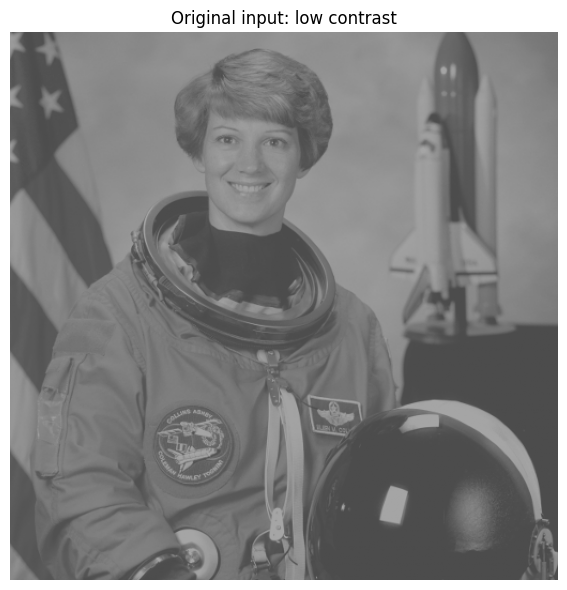

In [6]:
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Original input: low contrast")
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Display the original histogram

**How to read it:**

- The horizontal axis shows brightness: dark pixels on the left, bright pixels on the right.
- The vertical axis shows how many pixels have each brightness value.
- Taller bars mean more pixels at that brightness.
- A narrow occupied range means the image uses only a small part of the available brightness range.

**What the code means:** `gray.ravel()` puts all the image pixels into one long list.
`bins=256` gives one bin for each possible 8-bit brightness value. `range=(0, 256)` includes
the values from 0 through 255.

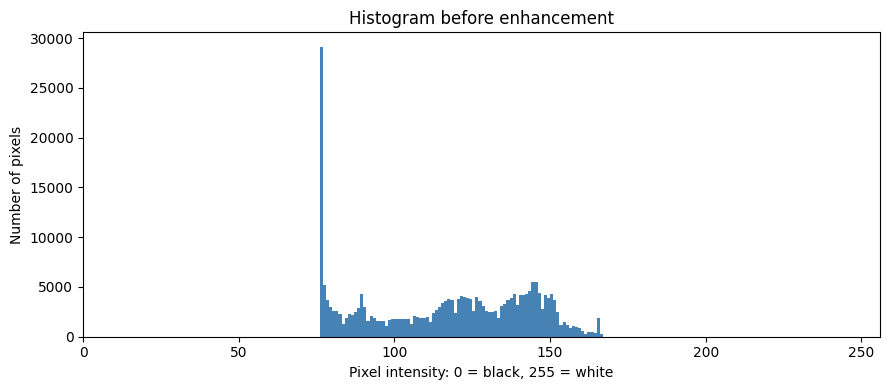

In [7]:
plt.figure(figsize=(9, 4))
plt.hist(gray.ravel(), bins=256, range=(0, 256), color="steelblue")
plt.title("Histogram before enhancement")
plt.xlabel("Pixel intensity: 0 = black, 255 = white")
plt.ylabel("Number of pixels")
plt.xlim(0, 256)
plt.tight_layout()
plt.savefig("figures/histogram_before.png", dpi=150)
plt.show()

## 5. Apply histogram equalization

Histogram equalization changes pixel brightness values to make better use of the available
brightness range. It can make differences between dark and bright regions easier to see.

OpenCV performs the calculation with the single function below. The pixel positions and
image dimensions stay the same; their brightness values change.

In [8]:
equalized = cv2.equalizeHist(gray)

## 6. Display the enhanced image

Compare the face, clothing, background, and dark helmet with the original input. The
enhanced image has stronger separation between dark and bright areas.

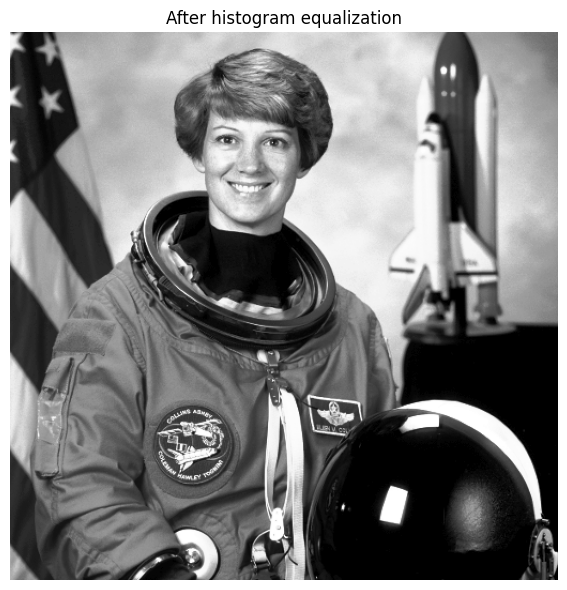

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.title("After histogram equalization")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Display the enhanced histogram

The occupied brightness levels now extend across a wider range. The histogram can still
have spikes and empty gaps. **Histogram equalization does not guarantee perfectly equal
bar heights**, especially when the input contains only a limited number of brightness levels.

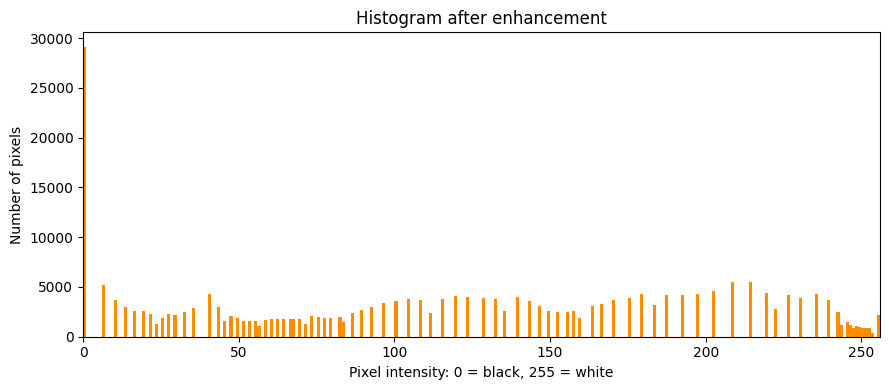

In [10]:
plt.figure(figsize=(9, 4))
plt.hist(equalized.ravel(), bins=256, range=(0, 256), color="darkorange")
plt.title("Histogram after enhancement")
plt.xlabel("Pixel intensity: 0 = black, 255 = white")
plt.ylabel("Number of pixels")
plt.xlim(0, 256)
plt.tight_layout()
plt.savefig("figures/histogram_after.png", dpi=150)
plt.show()

## 8. Compare the images and histograms

The images use the same brightness display limits. The two histograms below also share
the same horizontal and vertical scales, so their bar heights can be compared directly.
Use this figure when explaining the result in class.

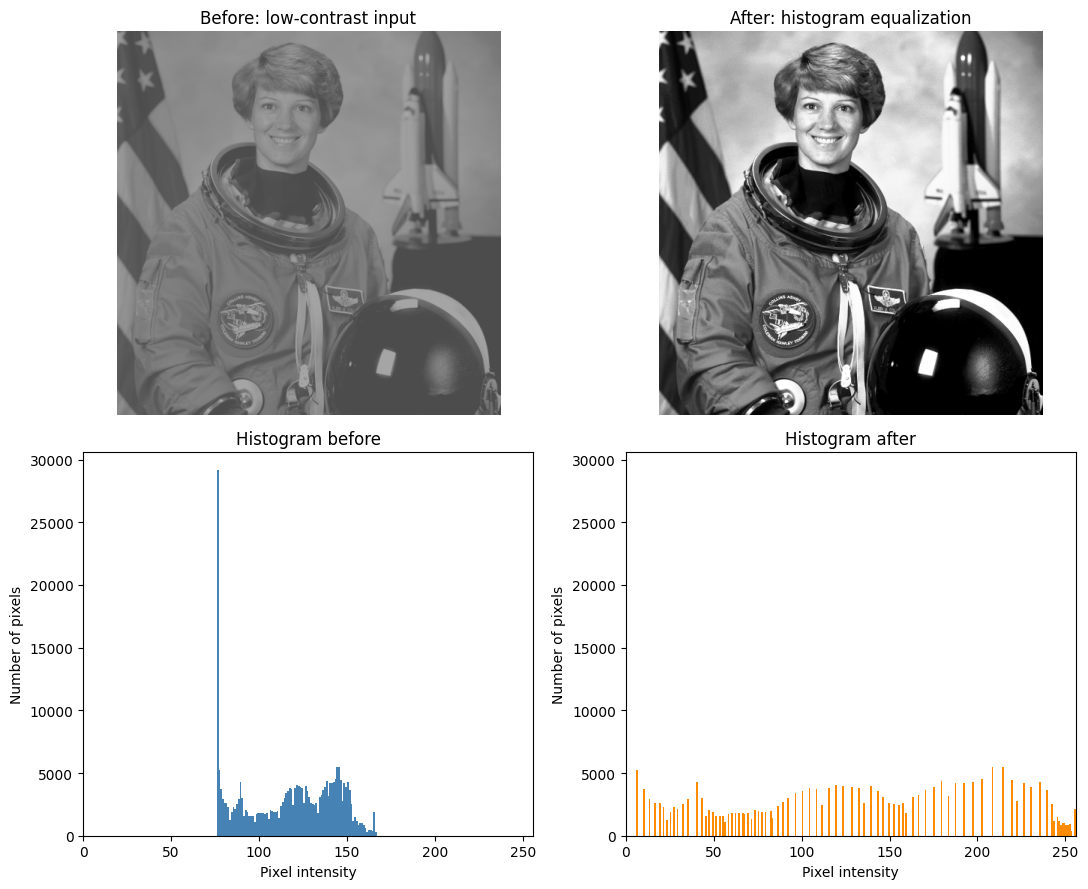

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Before: low-contrast input")
axes[0, 0].axis("off")

axes[0, 1].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("After: histogram equalization")
axes[0, 1].axis("off")

axes[1, 0].hist(gray.ravel(), bins=256, range=(0, 256), color="steelblue")
axes[1, 1].hist(equalized.ravel(), bins=256, range=(0, 256), color="darkorange")

shared_max = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
for ax in axes[1]:
    ax.set_xlim(0, 256)
    ax.set_ylim(0, shared_max)
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Number of pixels")

axes[1, 0].set_title("Histogram before")
axes[1, 1].set_title("Histogram after")

plt.tight_layout()
plt.savefig("figures/before_after_comparison.png", dpi=160)
plt.show()

## 9. Save the images

PNG preserves the processed pixel values without JPEG compression. The before-and-after
histograms and the combined comparison figure have already been saved in `figures/`.

In [12]:
saved_before = cv2.imwrite("images/original_gray.png", gray)
saved_after = cv2.imwrite("images/histogram_equalized.png", equalized)

if not (saved_before and saved_after):
    raise OSError("An output image could not be saved.")

print("Images and histogram figures saved successfully.")
print("Brightness values before:", int(gray.min()), "to", int(gray.max()))
print("Brightness values after:", int(equalized.min()), "to", int(equalized.max()))

Images and histogram figures saved successfully.
Brightness values before: 76 to 166
Brightness values after: 0 to 255


## 10. My Analysis

1. **Before enhancement:** the supplied input looks faded. Its brightness values occupy
   the limited range from **76 to 166**, which appears as a narrow group of bars in the histogram.
2. **After enhancement:** the brightness values extend from **0 to 255**. The dark helmet
   and clothing folds are more distinct from the brighter face and background.
3. **Histogram comparison:** the occupied brightness levels are spread more widely after
   processing. Some bars remain tall and there are gaps, that does not mean the method failed.
4. **Limitation:** the method increases contrast but does not create missing image detail.
   Some dark regions appear very strong, and the output may look less natural. A wider
   histogram is not sufficient by itself to prove that an image looks better.

These observations describe the supplied sample. If you change the image, inspect your new
plots and update the observations rather than keeping the same numerical range or conclusions.

## 11. Conclusion

Histogram equalization improved the visible contrast of the supplied low-contrast image.
The before-and-after images show stronger separation between dark and bright areas.
Their histograms show how the brightness distribution changed. Visual comparison and
histograms provide a simple way to explain the result without a mathematical derivation.

## Image source

The sample photograph of Eileen Collins comes from NASA and is distributed as
`skimage.data.astronaut()`. The scikit-image documentation identifies it as public domain:
https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.astronaut

The input used here is a simulated low-contrast grayscale derivative, included with the project.
Its appearance was deliberately flattened before this exercise. The source color photo is
included in `images/source_photo.png`; scikit-image is not required to run this notebook.